In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import clasificacion as C
import evaluation as EV

SEED = 42
SGNS_RUN = "d300_c100"

CACHE = Path("cache")
RESULTS = Path("results") / "clasificacion_sgns"
RESULTS.mkdir(parents=True, exist_ok=True)

archivos = [
    CACHE / "vocab.json",
    CACHE / "runs" / f"{SGNS_RUN}_W_in.npy",
]

for archivo in archivos:
    if not archivo.exists():
        raise FileNotFoundError(f"No se encontró: {archivo.resolve()}")

print("Archivos encontrados.")
print("Modelo:", SGNS_RUN)
print("Dispositivo de clasificación: CPU")
print("Resultados:", RESULTS.resolve())

Archivos encontrados.
Modelo: d300_c100
Dispositivo de clasificación: CPU
Resultados: /Users/Camila/Desktop/CAMILA UNIVERSIDAD/8SEMESTRE/DeepLearning/Lab7-DL/results/clasificacion_sgns


In [2]:
D = C.load_agnews(val_frac=0.1, seed=SEED)

with open(CACHE / "vocab.json", encoding="utf-8") as f:
    vocab_meta = json.load(f)

W = np.load(CACHE / "runs" / f"{SGNS_RUN}_W_in.npy")
assert W.shape[0] == len(vocab_meta["itos"]), (
    "Las filas de embeddings no coinciden con el vocabulario."
)

sgns_space = EV.EmbeddingSpace.from_itos(
    W, vocab_meta["itos"], name=SGNS_RUN
)

E, word2idx = C.embedding_table(sgns_space)
DIM = E.shape[1]
VOCAB_SIZE = E.shape[0]

datos = {
    split: C.Encoded(
        D[f"{split}_tok"],
        D[f"{split}_y"],
        word2idx,
    )
    for split in ["train", "val", "test"]
}

filas = []

for split in ["train", "val", "test"]:
    etiquetas = D[f"{split}_y"]
    conteos = np.bincount(etiquetas, minlength=len(C.CLASSES))

    filas.append({
        "split": split,
        "documentos": len(etiquetas),
        "tokens": sum(len(t) for t in D[f"{split}_tok"]),
        "OOV (%)": C.oov_pct(D[f"{split}_tok"], word2idx),
        **dict(zip(C.CLASSES, conteos.tolist())),
    })

resumen_datos = pd.DataFrame(filas).set_index("split")

print(f"Modelo: {SGNS_RUN}")
print(f"Dimensión: {DIM}")
print(f"Palabras del vocabulario: {len(sgns_space):,}")
print(f"Filas de la tabla, incluyendo <unk>: {VOCAB_SIZE:,}")
display(resumen_datos)

resumen_datos.to_csv(RESULTS / "datos_y_oov.csv")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Modelo: d300_c100
Dimensión: 300
Palabras del vocabulario: 109,644
Filas de la tabla, incluyendo <unk>: 109,645


,documentos,tokens,OOV (%),World,Sports,Business,Sci/Tech
split,,,,,,,
train,108000,4149307,3.728285,27000,27000,27000,27000
val,12000,460046,3.717672,3000,3000,3000,3000
test,7600,290684,3.640723,1900,1900,1900,1900


## Entrenamiento tabla congelada

In [3]:
modelo_congelado, info_congelado = C.train_classifier(
    train=datos["train"],
    val=datos["val"],
    vocab_size=VOCAB_SIZE,
    dim=DIM,
    pretrained=E,
    freeze=True,
    epochs=40,
    patience=3,
    batch_size=128,
    lr=1e-3,
    seed=SEED,
    verbose=True,
    name="SGNS-300/congelada",
)

info_congelado["sgns_run"] = SGNS_RUN

C.save_result(
    info_congelado,
    RESULTS / "sgns_congelado.json",
)

torch.save(
    modelo_congelado.state_dict(),
    RESULTS / "sgns_congelado.pt",
)

print("\nMejor epoch:", info_congelado["best_epoch"])
print("Parámetros totales:", f"{info_congelado['params_total']:,}")
print("Parámetros entrenables:", f"{info_congelado['params_trainable']:,}")
print(f"Tiempo: {info_congelado['train_time_s']:.1f} segundos")

display(
    pd.DataFrame(
        [info_congelado["val"]],
        index=["SGNS-300 congelado"],
    ).rename(columns={
        "acc": "Accuracy",
        "precision": "Precision macro",
        "recall": "Recall macro",
        "f1": "F1 macro",
        "loss": "Pérdida",
    })
)

[SGNS-300/congelada] epoch  1 | train 0.4315 val 0.3367 | val acc 0.8856 F1 0.8855 | 1.4s
[SGNS-300/congelada] epoch  2 | train 0.3363 val 0.3190 | val acc 0.8898 F1 0.8894 | 1.0s
[SGNS-300/congelada] epoch  3 | train 0.3222 val 0.3143 | val acc 0.8909 F1 0.8911 | 1.0s
[SGNS-300/congelada] epoch  4 | train 0.3145 val 0.3052 | val acc 0.8939 F1 0.8937 | 1.1s
[SGNS-300/congelada] epoch  5 | train 0.3079 val 0.3045 | val acc 0.8942 F1 0.8943 | 0.9s
[SGNS-300/congelada] epoch  6 | train 0.3026 val 0.2961 | val acc 0.8961 F1 0.8960 | 0.9s
[SGNS-300/congelada] epoch  7 | train 0.2982 val 0.2960 | val acc 0.8964 F1 0.8963 | 1.0s
[SGNS-300/congelada] epoch  8 | train 0.2948 val 0.2936 | val acc 0.8953 F1 0.8950 | 1.3s
[SGNS-300/congelada] epoch  9 | train 0.2914 val 0.2908 | val acc 0.8988 F1 0.8984 | 1.3s
[SGNS-300/congelada] epoch 10 | train 0.2871 val 0.2916 | val acc 0.8989 F1 0.8986 | 1.2s
[SGNS-300/congelada] epoch 11 | train 0.2849 val 0.2859 | val acc 0.9017 F1 0.9015 | 1.3s
[SGNS-300/

,Accuracy,Precision macro,Recall macro,F1 macro,Pérdida
SGNS-300 congelado,0.901667,0.901963,0.901667,0.901512,0.28586


## Entrenamiento fine tuning

In [4]:
resultados_ft = []
modelo_ft = None
info_ft = None
mejor_f1 = -float("inf")

for emb_lr in [1e-3, 1e-2]:
    print(f"\n=== Fine-tuning: learning rate embeddings = {emb_lr} ===")

    modelo, info = C.train_classifier(
        train=datos["train"],
        val=datos["val"],
        vocab_size=VOCAB_SIZE,
        dim=DIM,
        pretrained=E,
        freeze=False,
        epochs=40,
        patience=3,
        batch_size=128,
        lr=1e-3,          
        emb_lr=emb_lr,    
        seed=SEED,
        verbose=True,
        name=f"SGNS-300/ft_lr{emb_lr}",
    )

    info["sgns_run"] = SGNS_RUN
    C.save_result(
        info,
        RESULTS / f"sgns_finetuning_lr{emb_lr}.json",
    )

    resultados_ft.append({
        "emb_lr": emb_lr,
        "mejor_epoch": info["best_epoch"],
        "accuracy": info["val"]["acc"],
        "precision_macro": info["val"]["precision"],
        "recall_macro": info["val"]["recall"],
        "f1_macro": info["val"]["f1"],
        "tiempo_s": info["train_time_s"],
    })

    if info["val"]["f1"] > mejor_f1:
        mejor_f1 = info["val"]["f1"]
        modelo_ft = modelo
        info_ft = info

    del modelo

torch.save(
    modelo_ft.state_dict(),
    RESULTS / "sgns_finetuning_mejor.pt",
)
C.save_result(
    info_ft,
    RESULTS / "sgns_finetuning_mejor.json",
)

tabla_ft = pd.DataFrame(resultados_ft)
tabla_ft.to_csv(RESULTS / "comparacion_lr_finetuning.csv", index=False)

display(tabla_ft)
print("Learning rate elegido:", info_ft["config"]["emb_lr"])
print(f"Mejor F1 de validación: {info_ft['val']['f1']:.4f}")


=== Fine-tuning: learning rate embeddings = 0.001 ===
[SGNS-300/ft_lr0.001] epoch  1 | train 0.3450 val 0.2484 | val acc 0.9180 F1 0.9178 | 6.5s
[SGNS-300/ft_lr0.001] epoch  2 | train 0.2028 val 0.2359 | val acc 0.9203 F1 0.9202 | 6.1s
[SGNS-300/ft_lr0.001] epoch  3 | train 0.1566 val 0.2532 | val acc 0.9165 F1 0.9165 | 6.6s
[SGNS-300/ft_lr0.001] epoch  4 | train 0.1234 val 0.2787 | val acc 0.9130 F1 0.9130 | 5.3s
[SGNS-300/ft_lr0.001] epoch  5 | train 0.0990 val 0.3093 | val acc 0.9123 F1 0.9124 | 5.8s

=== Fine-tuning: learning rate embeddings = 0.01 ===
[SGNS-300/ft_lr0.01] epoch  1 | train 0.3163 val 0.2399 | val acc 0.9191 F1 0.9189 | 5.4s
[SGNS-300/ft_lr0.01] epoch  2 | train 0.1683 val 0.2530 | val acc 0.9189 F1 0.9189 | 6.2s
[SGNS-300/ft_lr0.01] epoch  3 | train 0.1148 val 0.3089 | val acc 0.9139 F1 0.9139 | 6.7s
[SGNS-300/ft_lr0.01] epoch  4 | train 0.0806 val 0.3952 | val acc 0.9118 F1 0.9119 | 6.9s
[SGNS-300/ft_lr0.01] epoch  5 | train 0.0600 val 0.4460 | val acc 0.9065 F1 

,emb_lr,mejor_epoch,accuracy,precision_macro,recall_macro,f1_macro,tiempo_s
0,0.001,2,0.920333,0.920667,0.920333,0.920232,30.626253
1,0.010,2,0.918917,0.919200,0.918917,0.918910,31.912807


Learning rate elegido: 0.001
Mejor F1 de validación: 0.9202


## Comparación y curvas de pérdida

,Accuracy,Precision macro,Recall macro,F1 macro
SGNS-300 fine-tuning,0.917105,0.917296,0.917105,0.91703


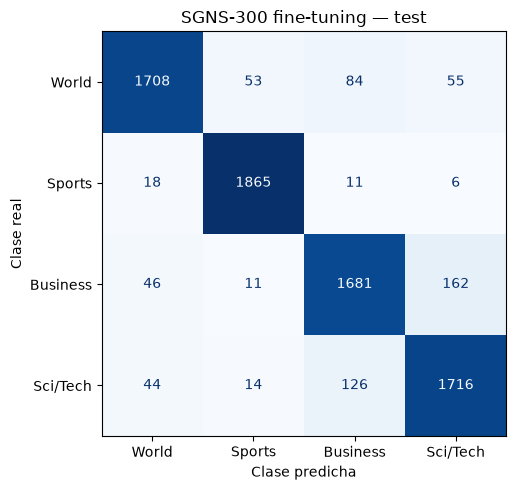

In [5]:
ruta_test = RESULTS / "test_sgns300.json"

if ruta_test.exists():
    with open(ruta_test, encoding="utf-8") as f:
        resultado_final = json.load(f)
    print("Resultado de test recuperado; no se repite la evaluación.")
else:
    resultado_test = C.evaluate_test(modelo_ft, datos["test"])

    resultado_final = {
        "sgns_run": SGNS_RUN,
        "variante": "fine-tuning",
        "emb_lr": info_ft["config"]["emb_lr"],
        "mejor_epoch": info_ft["best_epoch"],
        "seed": SEED,
        "test": resultado_test,
    }

    C.save_result(resultado_final, ruta_test)

r = resultado_final["test"]

display(pd.DataFrame([{
    "Accuracy": r["acc"],
    "Precision macro": r["precision"],
    "Recall macro": r["recall"],
    "F1 macro": r["f1"],
}], index=["SGNS-300 fine-tuning"]))

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=np.array(r["confusion"]),
    display_labels=C.CLASSES,
).plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("SGNS-300 fine-tuning — test")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.savefig(RESULTS / "matriz_confusion_test.png", dpi=200)
plt.show()